# Рекомендательная система для музыки: что выбрать и как это проверить

Ноутбук проходит весь путь: данные → три модели → метрики → проверка
значимости → эксперименты. Все графики строятся по ходу.

**Главный вопрос:** можно ли выбирать модель только по точности?

**Короткий ответ:** нет. Модель, которая точнее, может показывать
пользователю в десять раз меньшую часть каталога — и это выясняется,
только если специально измерить.

---

### Как запустить

По умолчанию ноутбук работает на **MovieLens-100k** — он лежит в
репозитории, ничего скачивать не нужно.

Чтобы прогнать на основном датасете (**Last.fm-360K**), скачайте его по
инструкции из `data/README.md` и поменяйте `DATASET` в следующей ячейке
на `"lastfm"`.

In [11]:
DATASET = "movielens"   # "lastfm" или "movielens"
K = 10                  # длина списка рекомендаций
N_SEEDS = 3             # сколько разбиений для оценки устойчивости

In [12]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


COLORS = {
    "Popularity": "#9aa0a6",
    "ItemCF": "#2d7dd2",
    "SVD-MF": "#e8871a",
    "Hybrid": "#7cb342",
}

## 1. Данные

Задача не похожа на обычную классификацию: у объектов нет признаков.
Есть только факт — **кто что слушал**. Вся информация в самих
взаимодействиях.

Это называется **implicit feedback**: пользователь не ставил оценок, мы
делаем вывод о вкусе по поведению. Отсюда важное следствие — ноль в
данных означает «не слышал», а не «не нравится». Различить эти два
случая невозможно.

In [13]:
from loaders import load_lastfm_360k, load_movielens_100k, describe, has_timestamps

if DATASET == "lastfm":
    df = load_lastfm_360k()
    TITLE = "Last.fm-360K"
else:
    df = load_movielens_100k()
    TITLE = "MovieLens-100k"

describe(df, TITLE)
df.head()


=== MovieLens-100k ===
Взаимодействий: 54,413
Пользователей:  938
Объектов:       1,008
Плотность:      5.7549%
На пользователя: медиана 39, среднее 58.0, макс 365


,user_id,item_id,weight,item_name,timestamp
0,0,0,4.0,Dr. Strangelove or: How I Learned to Stop Worr...,884182806
1,1,1,5.0,"Jungle Book, The (1994)",891628467
2,2,2,5.0,Romy and Michele's High School Reunion (1997),879781125
3,3,3,5.0,Star Trek: First Contact (1996),876042340
4,4,4,5.0,"Age of Innocence, The (1993)",879270459


### Насколько данные разреженные

Матрица «пользователи × объекты» почти пустая. Это не дефект выборки, а
норма для рекомендательных систем: человек физически не может
взаимодействовать с заметной долей каталога.

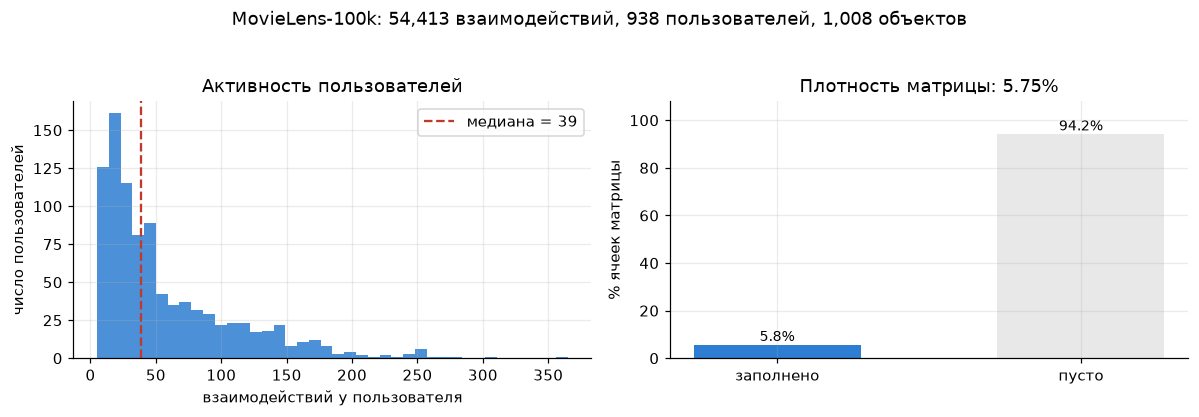

Плотная матрица заняла бы 0.00 ГБ, и 94.2% этого - нули.
Поэтому везде используются разреженные матрицы scipy.


In [14]:
n_users = df.user_id.nunique()
n_items = df.item_id.nunique()
density = len(df) / (n_users * n_items)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))


per_user = df.groupby("user_id").size()
axes[0].hist(per_user, bins=40, color="#2d7dd2", alpha=0.85)
axes[0].axvline(per_user.median(), color="#c0392b", ls="--", lw=1.5,
                label=f"медиана = {per_user.median():.0f}")
axes[0].set_xlabel("взаимодействий у пользователя")
axes[0].set_ylabel("число пользователей")
axes[0].set_title("Активность пользователей")
axes[0].legend()


axes[1].bar(["заполнено", "пусто"], [density * 100, (1 - density) * 100],
            color=["#2d7dd2", "#e8e8e8"], width=0.55)
axes[1].set_ylabel("% ячеек матрицы")
axes[1].set_title(f"Плотность матрицы: {density:.2%}")
for i, v in enumerate([density * 100, (1 - density) * 100]):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_ylim(0, 108)

plt.suptitle(f"{TITLE}: {len(df):,} взаимодействий, "
             f"{n_users:,} пользователей, {n_items:,} объектов", y=1.04)
plt.tight_layout()
plt.show()

print(f"Плотная матрица заняла бы {n_users * n_items * 4 / 1e9:.2f} ГБ, "
      f"и {(1-density)*100:.1f}% этого - нули.")
print("Поэтому везде используются разреженные матрицы scipy.")

### Длинный хвост

Популярность распределена крайне неравномерно: несколько объектов знают
все, а основная масса каталога почти никому не известна.

Это и есть причина, по которой **покрытие каталога** нужно измерять
отдельно. Модель легко может рекомендовать только левую часть графика.

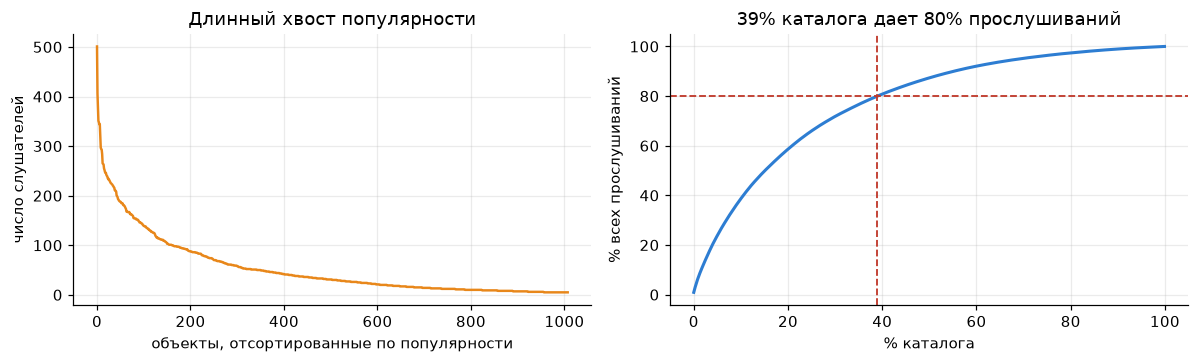

In [15]:
item_users = df.groupby("item_id").user_id.nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].plot(range(len(item_users)), item_users.values, color="#e8871a", lw=1.6)
axes[0].set_xlabel("объекты, отсортированные по популярности")
axes[0].set_ylabel("число слушателей")
axes[0].set_title("Длинный хвост популярности")

cumulative = item_users.cumsum() / item_users.sum()
axes[1].plot(np.arange(len(cumulative)) / len(cumulative) * 100,
             cumulative.values * 100, color="#2d7dd2", lw=2)
axes[1].axhline(80, color="#c0392b", ls="--", lw=1.2)
share_80 = (cumulative < 0.8).sum() / len(cumulative) * 100
axes[1].axvline(share_80, color="#c0392b", ls="--", lw=1.2)
axes[1].set_xlabel("% каталога")
axes[1].set_ylabel("% всех прослушиваний")
axes[1].set_title(f"{share_80:.0f}% каталога дает 80% прослушиваний")

plt.tight_layout()
plt.show()

## 2. Три модели

**Popularity** — рекомендуем всем самое популярное. Персонализации нет.
Нужен как планка: если сложная модель не обходит этот бейзлайн, она
бесполезна, потому что популярное можно показывать обычным запросом к базе.

**Item-based CF** — «объекты похожи, если их слушают одни и те же люди».
Считаем косинусное сходство между столбцами матрицы, рекомендуем то, что
похоже на уже прослушанное.

**Matrix Factorization (SVD)** — раскладываем матрицу на скрытые факторы.
Каждый пользователь и каждый объект получают координаты в пространстве
небольшой размерности; интерес — их скалярное произведение. В отличие от
CF модель обобщает и может связать объекты без прямых пересечений
аудитории.

In [16]:
from evaluate import make_split, evaluate, build_models
from recommender import build_user_item_matrix

train_df, test_df = make_split(df, mode="random", seed=0)
matrix = build_user_item_matrix(train_df, n_users=df.user_id.max()+1,
                                n_items=df.item_id.max()+1)

print(f"train: {len(train_df):,}   test: {len(test_df):,}")
print("У каждого пользователя спрятано 20% истории - ее модель и должна угадать.")

train: 43,536   test: 10,877
У каждого пользователя спрятано 20% истории - ее модель и должна угадать.


### Как выглядит рекомендация

Прежде чем считать метрики, посмотрим глазами: что модель советует
человеку с известной историей. Это базовая проверка на осмысленность —
если рекомендации выглядят случайными, дальше считать нечего.

In [17]:
from recommender import ItemBasedCF

names = df.drop_duplicates("item_id").set_index("item_id")["item_name"].to_dict()
itemcf = ItemBasedCF(top_k=200).fit(matrix)

demo_user = int(train_df.groupby("user_id").size().idxmax())
history = train_df[train_df.user_id == demo_user].nlargest(5, "weight")

print(f"Пользователь {demo_user} - что слушал (топ-5):")
for _, row in history.iterrows():
    print(f"   {names.get(row.item_id, '?')}")

print("\nЧто рекомендуем:")
for item_id, score in itemcf.recommend(demo_user, n=5):
    print(f"   {names.get(item_id, '?'):55s} score={score:.3f}")

Пользователь 437 - что слушал (топ-5):
   Star Wars (1977)
   Full Monty, The (1997)
   Jerry Maguire (1996)
   Rebel Without a Cause (1955)
   Dial M for Murder (1954)

Что рекомендуем:
   Raiders of the Lost Ark (1981)                          score=108.522
   When Harry Met Sally... (1989)                          score=95.827
   Casablanca (1942)                                       score=89.413
   Princess Bride, The (1987)                              score=87.688
   Apollo 13 (1995)                                        score=86.137


## 3. Метрики: почему точности недостаточно

Стандартные метрики отвечают на вопрос «сколько угадали»:

- **Precision@10** — доля полезного среди рекомендованного
- **Recall@10** — какую долю интересного нашли
- **NDCG@10** — то же, но с учетом позиции: попасть на первом месте
  ценнее, чем на десятом

Но есть вопрос, на который они не отвечают: **какую часть каталога
система вообще показывает?** Модель может быть точной и при этом
крутить одни и те же сто объектов — для сервиса это означает, что
остальная библиотека не существует.

Поэтому добавлены:

- **Coverage** — доля каталога, попавшая хоть в чьи-то рекомендации
- **AvgPopularity** — насколько выдача смещена к уже известному

Два списка рекомендаций, в обоих 2 попадания из 5:
  A - попадания наверху:  Precision=0.40   NDCG=1.000
  B - попадания внизу:    Precision=0.40   NDCG=0.501

Precision их не различает. NDCG - различает, и правильно:
пользователь смотрит список сверху и часто не доходит до конца.


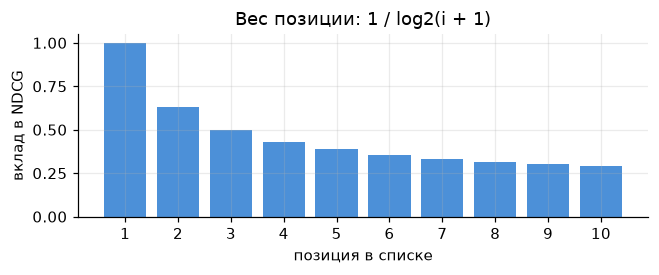

In [18]:
from evaluate import dcg

variant_a = [1, 1, 0, 0, 0]   # угадали на 1-й и 2-й позициях
variant_b = [0, 0, 0, 1, 1]   # угадали на 4-й и 5-й
ideal = dcg([1, 1])

print("Два списка рекомендаций, в обоих 2 попадания из 5:")
print(f"  A - попадания наверху:  Precision={sum(variant_a)/5:.2f}   NDCG={dcg(variant_a)/ideal:.3f}")
print(f"  B - попадания внизу:    Precision={sum(variant_b)/5:.2f}   NDCG={dcg(variant_b)/ideal:.3f}")
print("\nPrecision их не различает. NDCG - различает, и правильно:")
print("пользователь смотрит список сверху и часто не доходит до конца.")

fig, ax = plt.subplots(figsize=(6, 2.6))
positions = np.arange(1, 11)
ax.bar(positions, 1 / np.log2(positions + 1), color="#2d7dd2", alpha=0.85)
ax.set_xlabel("позиция в списке")
ax.set_ylabel("вклад в NDCG")
ax.set_title("Вес позиции: 1 / log2(i + 1)")
ax.set_xticks(positions)
plt.tight_layout()
plt.show()

## 4. Результаты

Каждая модель прогоняется на нескольких разбиениях — чтобы отличить
устойчивый результат от везения на одном сплите.

In [19]:
from evaluate import run_repeated

summary, all_runs = run_repeated(df, k=K, mode="random",
                                 seeds=tuple(range(N_SEEDS)), verbose=False)

cols = [f"NDCG@{K}", f"Precision@{K}", f"Recall@{K}", f"HitRate@{K}",
        "Coverage", "AvgPopularity"]
display_df = pd.DataFrame(index=summary.index)
for c in cols:
    display_df[c] = [f"{m:.4f} ± {s:.4f}"
                     for m, s in zip(summary[c], summary[c + "_std"])]
display_df

,NDCG@10,Precision@10,Recall@10,HitRate@10,Coverage,AvgPopularity
model,,,,,,
Popularity,0.1511 ± 0.0028,0.1146 ± 0.0023,0.1093 ± 0.0018,0.5974 ± 0.0040,0.0407 ± 0.0008,0.2811 ± 0.0013
ItemCF,0.2570 ± 0.0056,0.1824 ± 0.0036,0.2006 ± 0.0044,0.7637 ± 0.0079,0.1746 ± 0.0029,0.2186 ± 0.0026
SVD-MF,0.2194 ± 0.0032,0.1562 ± 0.0011,0.1882 ± 0.0023,0.7598 ± 0.0074,0.4203 ± 0.0094,0.1332 ± 0.0011
Hybrid,0.2194 ± 0.0032,0.1562 ± 0.0011,0.1882 ± 0.0023,0.7598 ± 0.0074,0.4203 ± 0.0094,0.1332 ± 0.0011


### Главный график

Слева — точность, справа — покрытие каталога. Сравните, как меняется
порядок моделей.

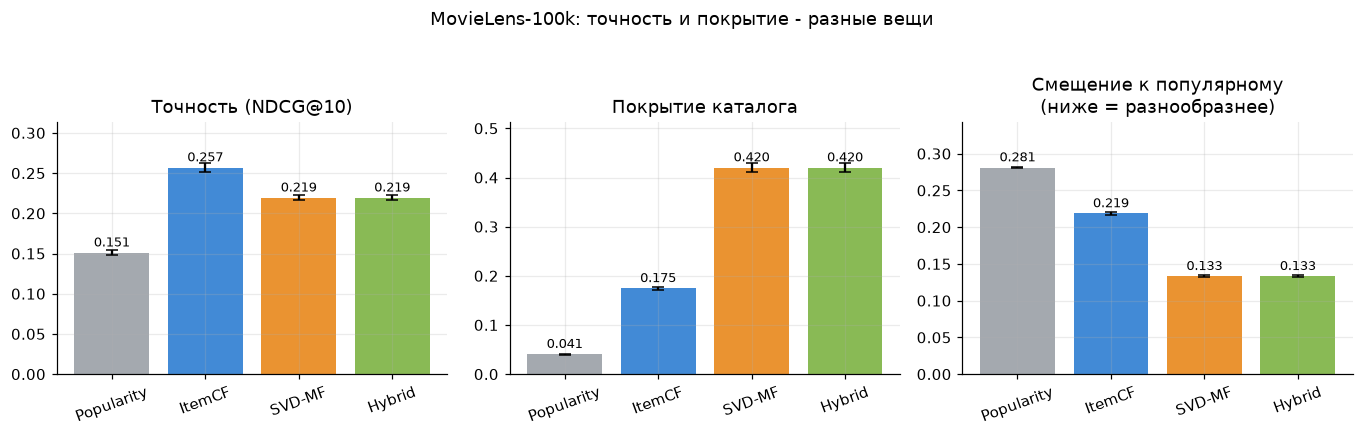

In [20]:
models = list(summary.index)
colors = [COLORS.get(m, "#888") for m in models]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))

for ax, metric, title in zip(
    axes,
    [f"NDCG@{K}", "Coverage", "AvgPopularity"],
    ["Точность (NDCG@10)", "Покрытие каталога", "Смещение к популярному"],
):
    values = summary[metric].values
    errors = summary[metric + "_std"].values
    bars = ax.bar(models, values, yerr=errors, capsize=4, color=colors, alpha=0.9)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + max(values) * 0.03,
                f"{v:.3f}", ha="center", fontsize=8.5)
    ax.set_ylim(0, max(values) * 1.22)

axes[2].set_title("Смещение к популярному\n(ниже = разнообразнее)")
plt.suptitle(f"{TITLE}: точность и покрытие - разные вещи", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

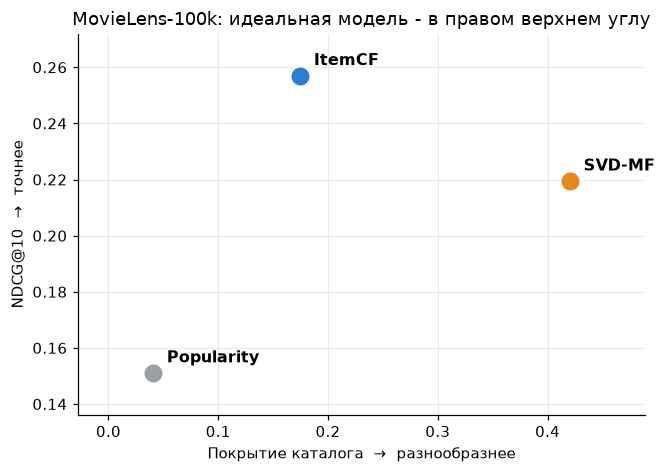

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 4.4))

for model in models:
    if model == "Hybrid":
        continue
    x = summary.loc[model, "Coverage"]
    y = summary.loc[model, f"NDCG@{K}"]
    ax.scatter(x, y, s=190, color=COLORS.get(model, "#888"),
               edgecolor="white", linewidth=2, zorder=3)
    ax.annotate(model, (x, y), xytext=(9, 7), textcoords="offset points",
                fontsize=10.5, weight="bold")

ax.set_xlabel("Покрытие каталога  →  разнообразнее")
ax.set_ylabel("NDCG@10  →  точнее")
ax.set_title(f"{TITLE}: идеальная модель - в правом верхнем углу")
ax.margins(x=0.18, y=0.14)
plt.tight_layout()
plt.show()

## 5. А это не шум?

Разница в третьем знаке ничего не значит сама по себе. Проверяем строго:

- метрики считаются **по каждому пользователю**, модели сравниваются
  попарно на одних и тех же людях
- критерий Уилкоксона — не требует нормальности, а распределения NDCG
  заведомо ненормальны (много нулей, ограничены сверху)
- бутстрап-интервал для средней разницы

In [22]:
from stats_tests import paired_test, format_comparison

run = all_runs[0]
by_name = {r["model"]: r for r in run}

pairs = [("ItemCF", "SVD-MF"), ("ItemCF", "Popularity"), ("SVD-MF", "Hybrid")]
for a, b in pairs:
    res = paired_test(by_name[a]["per_user"]["ndcg"],
                      by_name[b]["per_user"]["ndcg"], a, b)
    print(format_comparison(res, f"NDCG@{K}"))
    print()

ItemCF vs SVD-MF по NDCG@10:
  средние: 0.2641 против 0.2154
  разница: +0.0487 [95% ДИ: +0.0351, +0.0622]
  p-value = 2.23e-11
  размер эффекта: rank-biserial +0.274, Cohen's dz +0.231
  по пользователям: 488 за ItemCF, 306 за SVD-MF, 144 ничья
  ВЫВОД: разница ЗНАЧИМА, лучше ItemCF

ItemCF vs Popularity по NDCG@10:
  средние: 0.2641 против 0.1484
  разница: +0.1157 [95% ДИ: +0.1036, +0.1286]
  p-value < 1e-16
  размер эффекта: rank-biserial +0.693, Cohen's dz +0.605
  по пользователям: 567 за ItemCF, 172 за Popularity, 199 ничья
  ВЫВОД: разница ЗНАЧИМА, лучше ItemCF

SVD-MF vs Hybrid по NDCG@10:
  средние: 0.2154 против 0.2154
  разница: +0.0000 [95% ДИ: +0.0000, +0.0000]
  p-value = 1.00e+00
  размер эффекта: rank-biserial +0.000, Cohen's dz +0.000
  по пользователям: 0 за SVD-MF, 0 за Hybrid, 938 ничья
  ВЫВОД: разница НЕ значима (может быть шумом)



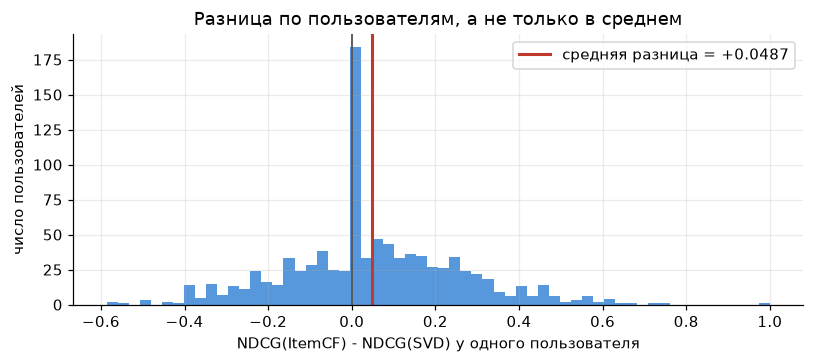

ItemCF лучше у 488 пользователей, SVD лучше у 306, ничья у 144.
Среднее скрывает, что у заметной части людей побеждает другая модель.


In [23]:
# распределение разниц по пользователям
res = paired_test(by_name["ItemCF"]["per_user"]["ndcg"],
                  by_name["SVD-MF"]["per_user"]["ndcg"], "ItemCF", "SVD-MF")
diff = by_name["ItemCF"]["per_user"]["ndcg"] - by_name["SVD-MF"]["per_user"]["ndcg"]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.hist(diff, bins=60, color="#2d7dd2", alpha=0.8)
ax.axvline(0, color="#555", lw=1.2)
ax.axvline(diff.mean(), color="#c0392b", lw=2,
           label=f"средняя разница = {diff.mean():+.4f}")
ax.set_xlabel("NDCG(ItemCF) - NDCG(SVD) у одного пользователя")
ax.set_ylabel("число пользователей")
ax.set_title("Разница по пользователям, а не только в среднем")
ax.legend()
plt.tight_layout()
plt.show()

print(f"ItemCF лучше у {res['wins_a']:,} пользователей, "
      f"SVD лучше у {res['wins_b']:,}, ничья у {res['ties']:,}.")
print("Среднее скрывает, что у заметной части людей побеждает другая модель.")

## 6. А это не артефакт настройки?

Сравнивать модели на произвольно выбранных гиперпараметрах некорректно:
может оказаться, что мы сравнили удачную конфигурацию с неудачной.
Прогоняем главный параметр каждой модели по сетке.

> Важно: развертка считается на тестовой выборке. Это годится для
> диагностики — понять характер зависимости, — но выбирать по ней лучшее
> значение нельзя, это подбор гиперпараметра по тесту. Для честного
> выбора нужна отдельная валидационная выборка.

In [24]:
from sweep import sweep

factors = [8, 16, 32, 64, 128] if DATASET == "movielens" else [32, 64, 128, 256]
svd_sweep = sweep(df, param="n_factors", values=factors, k=K, verbose=False)
svd_sweep[["n_factors", f"NDCG@{K}", "Coverage", "AvgPopularity"]].round(4)

,n_factors,NDCG@10,Coverage,AvgPopularity
model,,,,
SVD n_factors=8,8,0.2879,0.1954,0.1970
SVD n_factors=16,16,0.3012,0.2649,0.1805
SVD n_factors=32,32,0.2718,0.3363,0.1596
SVD n_factors=64,64,0.2154,0.4335,0.1322
SVD n_factors=128,128,0.1508,0.5625,0.0974


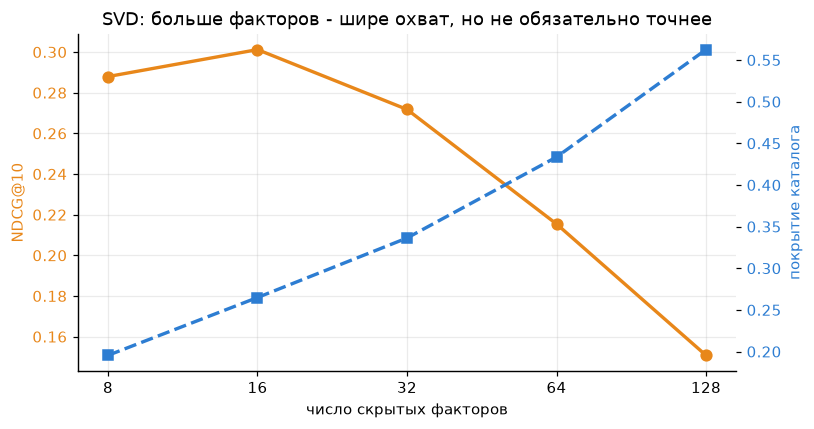

In [25]:
fig, ax1 = plt.subplots(figsize=(7.5, 4))

x = svd_sweep["n_factors"].values
ax1.plot(x, svd_sweep[f"NDCG@{K}"].values, "o-", color="#e8871a",
         lw=2.2, ms=7, label="NDCG@10")
ax1.set_xlabel("число скрытых факторов")
ax1.set_ylabel("NDCG@10", color="#e8871a")
ax1.tick_params(axis="y", labelcolor="#e8871a")
ax1.set_xscale("log", base=2)
ax1.set_xticks(x)
ax1.set_xticklabels(x)

ax2 = ax1.twinx()
ax2.plot(x, svd_sweep["Coverage"].values, "s--", color="#2d7dd2",
         lw=2.2, ms=7, label="Coverage")
ax2.set_ylabel("покрытие каталога", color="#2d7dd2")
ax2.tick_params(axis="y", labelcolor="#2d7dd2")
ax2.grid(False)

plt.title("SVD: больше факторов - шире охват, но не обязательно точнее")
fig.tight_layout()
plt.show()

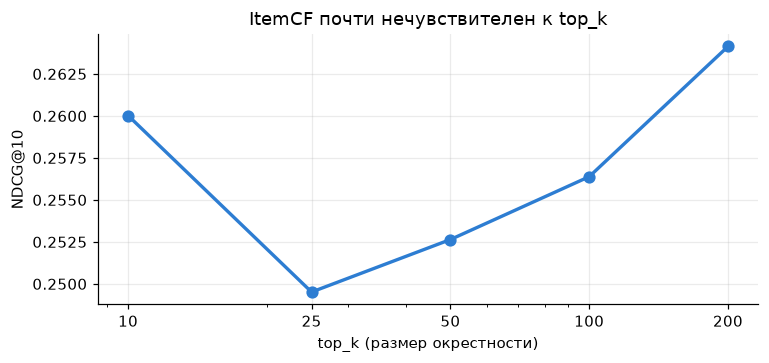

,top_k,NDCG@10,Coverage
model,,,
ItemCF top_k=10,10,0.2600,0.2748
ItemCF top_k=25,25,0.2495,0.2034
ItemCF top_k=50,50,0.2526,0.1786
ItemCF top_k=100,100,0.2564,0.1766
ItemCF top_k=200,200,0.2641,0.1786


In [26]:
top_ks = [10, 25, 50, 100, 200] if DATASET == "movielens" else [50, 200, 500, 1000]
cf_sweep = sweep(df, param="top_k", values=top_ks, k=K, verbose=False)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(cf_sweep["top_k"], cf_sweep[f"NDCG@{K}"], "o-",
        color="#2d7dd2", lw=2.2, ms=7)
ax.set_xlabel("top_k (размер окрестности)")
ax.set_ylabel("NDCG@10")
ax.set_xscale("log")
ax.set_xticks(top_ks)
ax.set_xticklabels(top_ks)
ax.set_title("ItemCF почти нечувствителен к top_k")
plt.tight_layout()
plt.show()

cf_sweep[["top_k", f"NDCG@{K}", "Coverage"]].round(4)

## 7. Холодный старт: проверка собственного решения

Ни CF, ни MF не могут ничего сказать о пользователе без истории. Я
заложил переключение на популярность как безопасную страховку для
новичков — решение выглядит очевидно правильным.

Проверяем: искусственно урезаем историю 15% пользователей до одного
взаимодействия и оцениваем **только на них**.

In [27]:
from cold_start import run_cold_start_experiment

cold = run_cold_start_experiment(df, k=K)
cold[[f"NDCG@{K}", f"Precision@{K}", "Coverage", "AvgPopularity"]].round(4)

Пользователей-новичков: 140 (история урезана до 1 взаимодействия)
Тестовых взаимодействий у них: 1,866



,NDCG@10,Precision@10,Coverage,AvgPopularity
model,,,,
Popularity,0.0947,0.0707,0.0109,0.2621
SVD-MF (без fallback),0.0934,0.0650,0.2907,0.1232
Hybrid (SVD + fallback),0.0947,0.0707,0.0109,0.2621


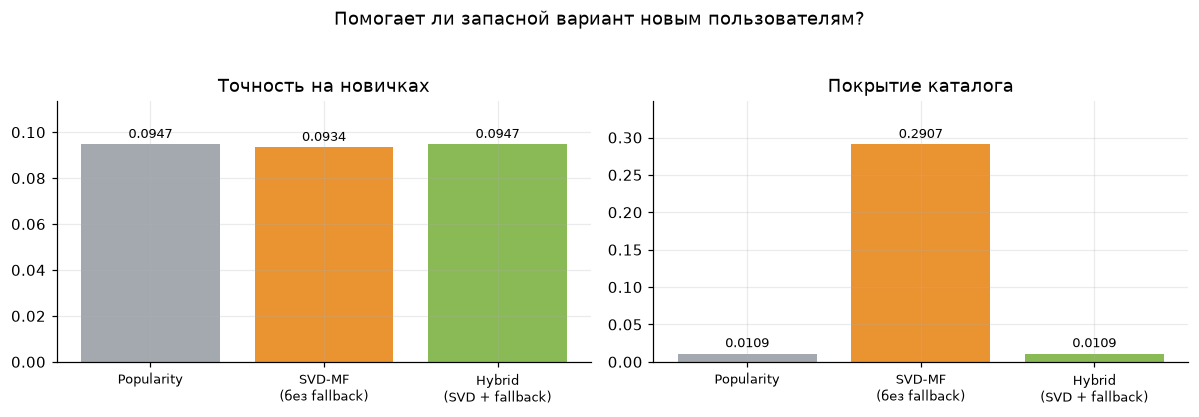

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
labels = [i.replace(" (", "\n(") for i in cold.index]
cold_colors = ["#9aa0a6", "#e8871a", "#7cb342"]

for ax, metric, title in zip(axes, [f"NDCG@{K}", "Coverage"],
                             ["Точность на новичках", "Покрытие каталога"]):
    values = cold[metric].values
    bars = ax.bar(labels, values, color=cold_colors, alpha=0.9)
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=8.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(values)*0.03,
                f"{v:.4f}", ha="center", fontsize=8.5)
    ax.set_ylim(0, max(values) * 1.2)

plt.suptitle("Помогает ли запасной вариант новым пользователям?", y=1.04)
plt.tight_layout()
plt.show()

Результат зависит от датасета, и это самое интересное место ноутбука.

На **Last.fm** запасной вариант оказывается **вредным**: чистый SVD дает
и более точные рекомендации, и в десятки раз более широкий охват. Одного
прослушивания уже достаточно, чтобы персонализация била топ чартов.

На **MovieLens** картина другая — популярность слегка выигрывает в
точности, но обрушивает покрытие.

Общий вывод в обоих случаях один: порог переключения — **продуктовое
решение** о том, чем сервис жертвует ради безопасной выдачи новичку, а
не параметр, который подбирают по метрике. И проверять такие «очевидно
правильные» решения нужно экспериментом.

## 8. Что из этого следует

**Точность и разнообразие — разные оси, и порядок моделей по ним не
совпадает.** Выбор по одной метрике приводит к системе, которая хорошо
угадывает, но показывает малую часть каталога.

**Выводы не переносятся между доменами.** На музыке ItemCF выигрывает по
обеим осям; на фильмах SVD покрывает каталог в 2.4 раза лучше. Одно и то
же утверждение верно на одних данных и неверно на других — полная
таблица сравнения в README.

**Собственные проектные решения нужно проверять.** Запасной вариант для
новичков выглядел очевидно правильным и на музыкальных данных оказался
вредным.

**Разница в метриках требует проверки на значимость.** Без парного теста
и интервалов третий знак после запятой ничего не значит.

### Ограничения

- В Last.fm-360K нет таймстампов, поэтому сплит случайный. На MovieLens,
  где время есть, честный временной сплит роняет метрики примерно на 45% —
  случайное разбиение заметно завышает качество.
- SVD трактует нули implicit feedback как «не нравится», хотя это
  «не слышал». Корректнее ALS с confidence weighting.
- Оценка офлайновая: она измеряет способность угадать то, что человек и
  так послушал бы. Реальный эффект от роста покрытия покажет только
  онлайн-эксперимент.

Подробности, полные таблицы и обоснование инженерных решений — в `README.md`.